In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WP = Path.cwd()  # run the notebook from inside Wpower/
turbines = pd.read_csv(WP / "turbines.csv")
farms    = pd.read_csv(WP / "farms.csv")
power    = pd.read_csv(WP / "power_obs.csv", index_col=0, parse_dates=True)

REG_COLOR = {"BE": "#1f77b4", "UK": "#d62728"}
print(f"{len(turbines)} turbines, {len(farms)} farms, "
      f"power {power.shape[0]} rows x {power.shape[1]} farms")


2380 turbines, 31 farms, power 16312 rows x 31 farms


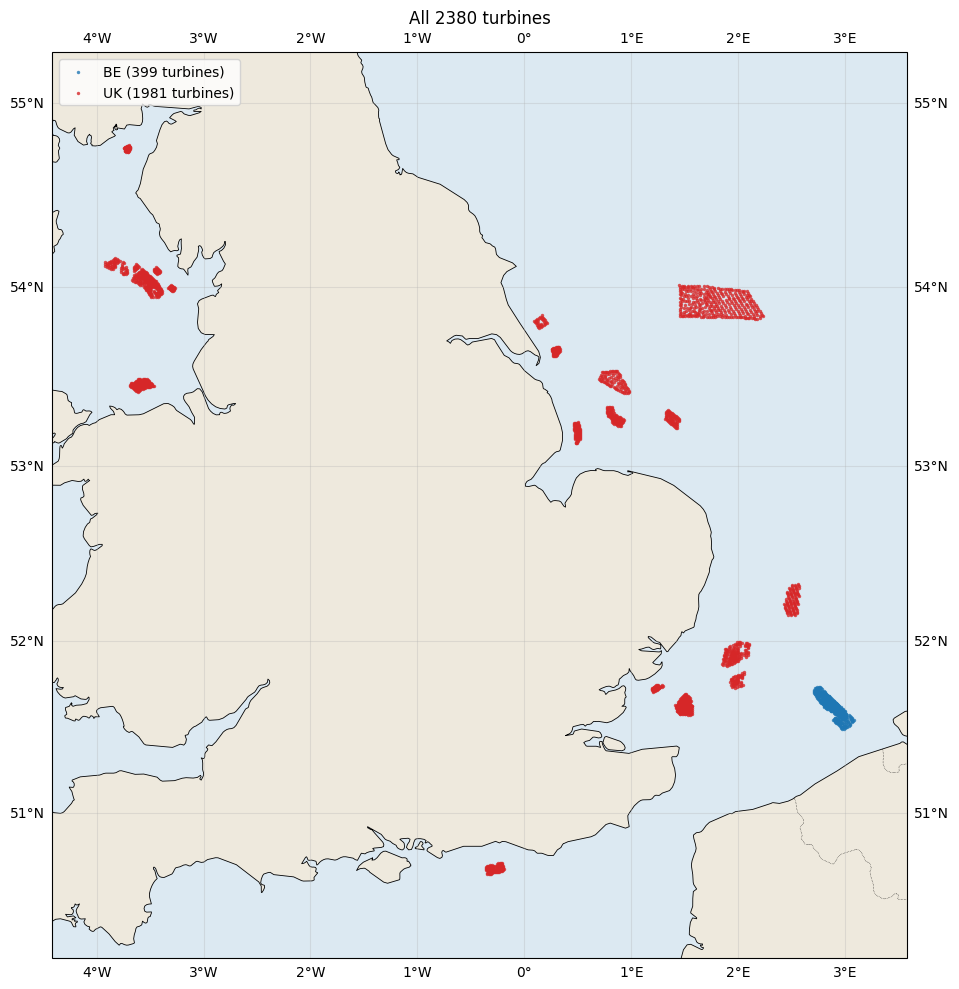

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

DATA = ccrs.PlateCarree()   # our coordinates are lon/lat
pad = 0.5
ext = [turbines.longitude.min() - pad, turbines.longitude.max() + pad,
       turbines.latitude.min()  - pad, turbines.latitude.max()  + pad]

fig = plt.figure(figsize=(11, 10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(ext, crs=DATA)
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#eee9dd")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#dce9f2")
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), lw=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), lw=0.4, ls=":")
ax.gridlines(draw_labels=True, alpha=0.3)

for reg, g in turbines.groupby("region"):
    ax.scatter(g.longitude, g.latitude, s=6, c=REG_COLOR[reg], transform=DATA,
               label=f"{reg} ({len(g)} turbines)", alpha=0.8, linewidths=0, zorder=5)
ax.legend(loc="upper left")
ax.set_title(f"All {len(turbines)} turbines")
plt.tight_layout(); plt.show()



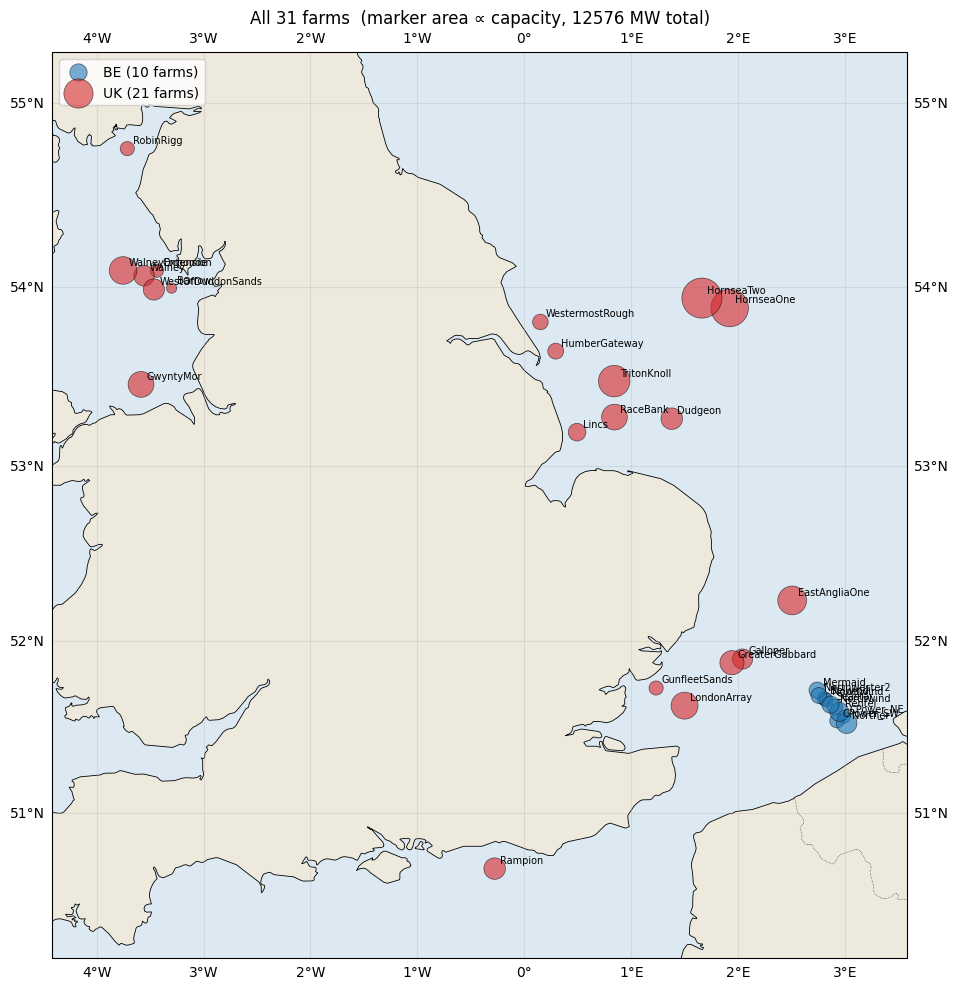

In [3]:
cen = (turbines.groupby("farm")
       .agg(lon=("longitude", "mean"), lat=("latitude", "mean"))
       .join(farms.set_index("farm")[["region", "capacity_mw", "n_turbines"]]))

fig = plt.figure(figsize=(11, 10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(ext, crs=DATA)                 # reuse ext from cell 2
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#eee9dd")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#dce9f2")
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), lw=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), lw=0.4, ls=":")
ax.gridlines(draw_labels=True, alpha=0.3)

for reg, g in cen.groupby("region"):
    ax.scatter(g.lon, g.lat, s=g.capacity_mw * 0.6, c=REG_COLOR[reg], transform=DATA,
               label=f"{reg} ({len(g)} farms)", alpha=0.6,
               edgecolors="k", linewidths=0.5, zorder=5)
for name, r in cen.iterrows():
    ax.annotate(name, (r.lon, r.lat), transform=DATA, fontsize=7,
                xytext=(4, 4), textcoords="offset points", zorder=6)
ax.legend(loc="upper left")
ax.set_title(f"All {len(cen)} farms  (marker area ∝ capacity, {cen.capacity_mw.sum():.0f} MW total)")
plt.tight_layout(); plt.show()



In [4]:
# --- pick the day -------------------------------------------------------------
DAY = "2020-1-15"           # e.g. "2023-04-15" to hardcode; None = random day with data

days = power.index.normalize().unique()
if DAY is not None:
    day = pd.Timestamp(DAY, tz="UTC")
    if day not in days:
        raise ValueError(f"{DAY} not in data ({days.min().date()} .. {days.max().date()})")
    d = power.loc[power.index.normalize() == day]
    reporting = d.columns[d.notna().any()].tolist()
    if not reporting:
        raise ValueError(f"{DAY} has no reporting farms — pick another date")
else:
    rng = np.random.default_rng()      # seed for reproducibility, e.g. default_rng(0)
    while True:
        day = days[rng.integers(len(days))]
        d = power.loc[power.index.normalize() == day]
        reporting = d.columns[d.notna().any()].tolist()
        if reporting:
            break

# --- print --------------------------------------------------------------------
d = d[reporting].copy()
d.index = d.index.strftime("%H:%M")    # just the time-of-day (UTC)

print(f"{day.date()}  —  {len(reporting)} of {power.shape[1]} farms reporting")
print("power in MW (value = mean over [t, t+3h), UTC)\n")
with pd.option_context("display.max_columns", None, "display.width", 200,
                       "display.float_format", lambda x: f"{x:6.1f}"):
    print(d.T)                         # farms as rows, times as columns

print(f"\nfleet total per timestep (MW):")
print(d.sum(axis=1).round(1).to_string())



2020-01-15  —  22 of 31 farms reporting
power in MW (value = mean over [t, t+3h), UTC)

time               00:00  03:00  06:00  09:00  12:00  15:00  18:00  21:00
Belwind            146.0  145.7  146.0  137.7   51.3   96.7  125.7   93.7
Nobelwind          159.0  159.0  159.0  156.0   70.7  122.3  151.7  134.7
CPower_SW          165.0  164.7  164.3  164.3   60.0   86.3  150.7  121.0
CPower_NE          142.7  137.3  136.3  136.0   47.7   43.3   84.0   65.7
Norther            342.7  335.0  337.0  345.0  169.0  193.7  321.3  293.7
Northwester2        14.0   15.0   16.7   15.7    3.7    9.3   17.3   18.0
Northwind          209.0  209.0  209.0  208.0   86.0  128.0  183.7  139.0
Rentel             303.0  303.0  303.0  303.0  118.0  163.7  260.3  220.7
Dudgeon            243.4  152.5  273.5  287.8  339.8  355.1  363.5  365.2
GreaterGabbard     456.4  459.1  434.8  193.9  174.3  423.3  455.7  421.0
GunfleetSands      153.1  151.5   91.1   30.0   78.9  121.2  148.7  135.9
GwyntyMor          509.8

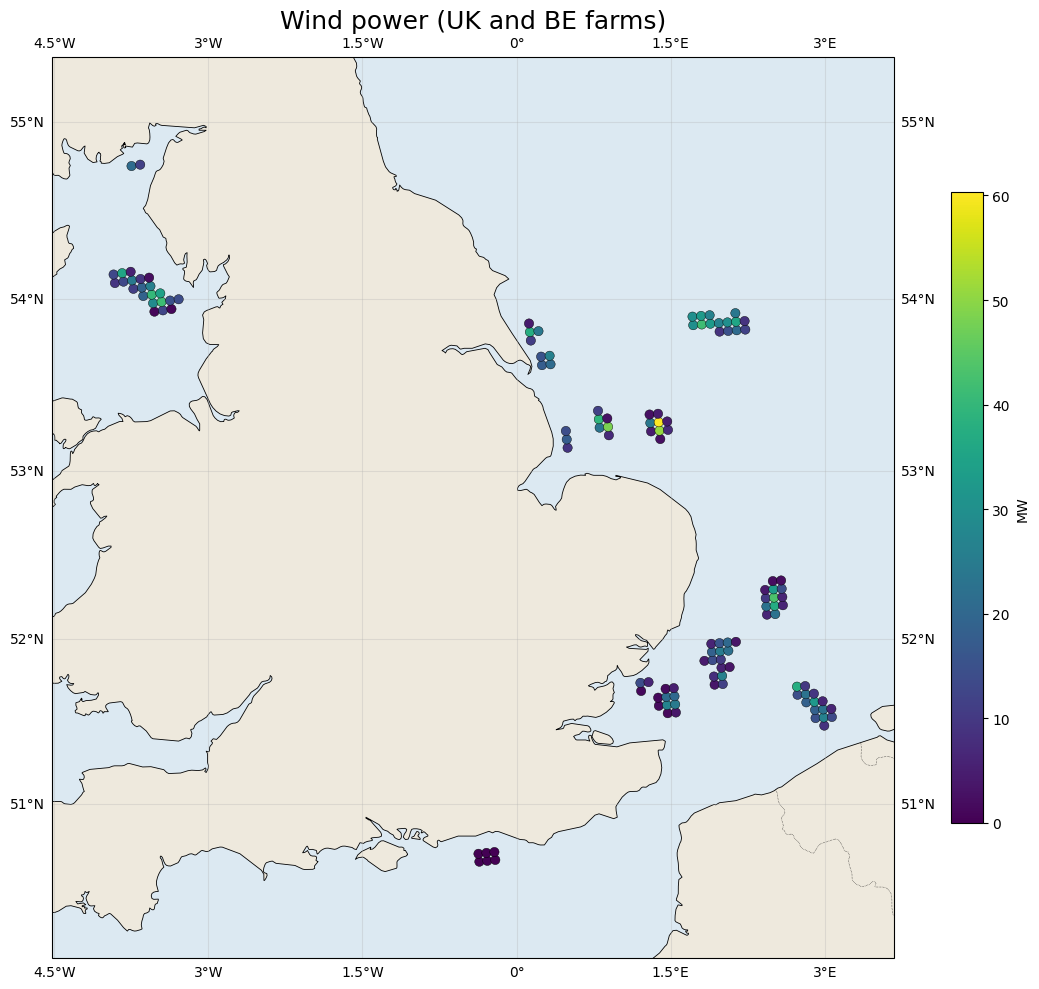

127 cells lit, total 2078 MW


In [6]:
import xarray as xr, numpy as np, pandas as pd, matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature

z = xr.open_zarr("power_cerra_src.zarr", consolidated=True)

VAR  = "power"                 # "power" (MW) or "capacityfactor" ([0,1])
DATE = "2021-11-05 12:00"      # hardcode a UTC time, or None for a well-populated one

# --- pick the timestep ---
if DATE is None:
    t = int(np.argmax(np.isfinite(z[VAR]).sum("values").values))
else:
    times = pd.DatetimeIndex(z.time.values)
    t = int(times.get_indexer([pd.Timestamp(DATE)], method="nearest")[0])
when = str(z.time.values[t])[:16]

v = z[VAR].isel(time=t).values
lat, lon = z["latitude"].values, z["longitude"].values
m = np.isfinite(v)

# --- map ---
DATA = ccrs.PlateCarree()
pad = 0.6
ext = [lon[m].min()-pad, lon[m].max()+pad, lat[m].min()-pad, lat[m].max()+pad]

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(ext, crs=DATA)
ax.add_feature(cfeature.LAND.with_scale("10m"),  facecolor="#eee9dd")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#dce9f2")
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), lw=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("10m"),   lw=0.4, ls=":")
ax.gridlines(draw_labels=True, alpha=0.3)

sc = ax.scatter(lon[m], lat[m], c=v[m], s=45, cmap="viridis", transform=DATA,
                edgecolors="k", linewidths=0.3, zorder=5,
                vmin=0, vmax=(1.0 if VAR == "capacityfactor" else None))
plt.colorbar(sc, ax=ax, shrink=0.7,
             label="MW" if VAR == "power" else "capacity factor")
ax.set_title(f"Wind power (UK and BE farms)",fontsize=18)
plt.savefig("UKBE.png")
plt.tight_layout(); plt.show()

print(f"{m.sum()} cells lit, total {np.nansum(v):.0f}"
      f"{' MW' if VAR == 'power' else ' (sum of CF)'}")



In [9]:
z.isel(time=20000)['power']

<xarray.DataArray 'power' (values: 72668)> Size: 291kB
dask.array<getitem, shape=(72668,), dtype=float32, chunksize=(72668,), chunktype=numpy.ndarray>
Coordinates:
    latitude   (values) float32 291kB dask.array<chunksize=(36334,), meta=np.ndarray>
    longitude  (values) float32 291kB dask.array<chunksize=(36334,), meta=np.ndarray>
    time       datetime64[ns] 8B 2021-11-05
Dimensions without coordinates: values